# Shadow3 CAX simulation

Notebook to test Shadow3's scripting capabilities and relate OASYS properties with Shadow attributes.

In [15]:
#
# Python script to run shadow3. Created automatically with ShadowTools.make_python_script_from_list().
#
import Shadow
import numpy

In [27]:
# Initialize beam and source (Bending Magnet)
beam = Shadow.Beam()
oe0 = Shadow.Source()


#
# Define variables. See meaning of variables in: 
#  https://raw.githubusercontent.com/srio/shadow3/master/docs/source.nml 
#

# Bending magnet properties

# Beam energy GeV
oe0.BENER  = 3.0
# Emittance x in mm rad
oe0.EPSI_X = 2.5e-07
# Emittance z in mm rad
oe0.EPSI_Z = 2.5e-09
# source angle distribution types: 
# (4) Synchrotron radiation
oe0.FDISTR = 4
# defines the source depth (Y): 
# synchrotron depth (4)
oe0.FSOURCE_DEPTH = 4
# photon energy distribution type: 
# uniform energy distribution (3)
oe0.F_COLOR = 3
# defines whether the photon energy will be
# specified in eV (0) or angstrons (1)
oe0.F_PHOT = 0
# Horizontal half divergences in rad
oe0.HDIV1 = 0.0002
oe0.HDIV2 = 0.0002
# seed for random number generator 
# 0=clock
oe0.ISTAR1 = 1
# "source generation routines will fill in the
# number of columns in your source"
oe0.NCOL = 0
# Number of rays to be traced
oe0.NPOINT = 1000000
# num of colors if f_color = 2 (does not apply here)
oe0.N_COLOR = 0
# Min and max photon energy in eV
oe0.PH1 = 10999.0
oe0.PH2 = 11001.0
# for f_polar=1; degree of polarization (does not apply here)
oe0.POL_DEG = 0.0
# Magnetic radius in mm and m
oe0.R_ALADDIN = 17736.481488735484
oe0.R_MAGNET = 17.736481488735485
# sigma in rad for gaussian distribution of angles (not used here)
oe0.SIGDIX = 0.0
oe0.SIGDIZ = 0.0
# Sigmas in mm
oe0.SIGMAX = 0.0199
oe0.SIGMAY = 0.0
oe0.SIGMAZ = 0.0115
# Vertical half divergences in rad
oe0.VDIV1 = 1.0
oe0.VDIV2 = 1.0
# for fsour=1,2; source dimensions
oe0.WXSOU = 0.0
oe0.WYSOU = 0.0
oe0.WZSOU = 0.0

oe0.write("source.props")

In [28]:
#  Initialize toroidal mirror
#  https://raw.githubusercontent.com/srio/shadow3/master/docs/oe.nml
#

oe1 = Shadow.OE()

# OE orientation angle in deg
oe1.ALPHA = 90.0
# Conversion factor from user units (length) to cm 
# ( 1.0 if cm, 0.1 if mm, 100.0 if m)
oe1.DUMMY = 0.1
# flag: mirror dimensions finite: 
# yes (1), no(0)
oe1.FHIT_C = 1
# mirror surface:
# toroidal (3)
oe1.FMIRR = 3
# files to save option: all files (0), mirror file
#only -- mirr (1), image file only -- star (2) 
# none (3).
oe1.FWRITE = 2
# flag for internal/calculated (0) parameters vs. 
# external/user defined parameters (1)
oe1.F_EXT = 1
# move mirror 
# yes (1), no (0)
oe1.F_MOVE = 1
# fshape=1: mirror half length +Y.
# fshape=3: internal minor axis (Y)
oe1.RLEN1 = 110.0
# fshape=1: mirror half length -Y.
# fshape=2, 3: external outline axis (Y)
oe1.RLEN2 = 110.0
# fshape=1: mirror half width +X.
# fshape=3: internal major axis (X).
oe1.RWIDX1 = 4.0
# fshape=1: mirror half width -X.
# fshape=2,3: external outline major axis (X).
oe1.RWIDX2 = 4.0
# f_ext=1, fmirr=3: tangential (major) axis.
oe1.R_MAJ = 901300.0
# f_ext=1, fmirr=3: sagittal (minor) axis.
oe1.R_MIN = 318.4
# Image plane distance from mirror in mm
oe1.T_IMAGE = 0.0
# Angle of incidence in deg, relative to the surface normal
oe1.T_INCIDENCE = 88.924
# Angle of reflection in deg, relative to the surface normal
oe1.T_REFLECTION = 88.924
# Source plane distance from mirror in mm
oe1.T_SOURCE = 17000.0

# Offsets
oe1.OFFX = 0.0
oe1.OFFY = 0.0
oe1.OFFZ = 0.0

# Rotations
oe1.X_ROT = 0.0
oe1.Y_ROT = 0.0
oe1.Z_ROT = 0.0

oe1.write("mirror.props")

fixing poolOE for Fortran
fixed poolOE for Fortran


In [29]:
# Empty element to realign
# coordinate system

oe2 = Shadow.OE()

# Conversion factor from user units (length) to cm 
# ( 1.0 if cm, 0.1 if mm, 100.0 if m)
oe2.DUMMY = 0.1
# files to save option: all files (0), mirror file
#only -- mirr (1), image file only -- star (2) 
# none (3).
oe2.FWRITE = 3
# reflector (0). refractor (1), empty element (2).
oe2.F_REFRAC = 2
# image plane distance from element in mm
oe2.T_IMAGE = 0.0
# angle of incidence in deg, relative to the surface normal
oe2.T_INCIDENCE = 90.0
# angle of reflection in deg, relative to the surface normal
oe2.T_REFLECTION = 90.0
# source plane distance from element in mm
oe2.T_SOURCE = 4359.0

oe2.write("empty_element.props")

fixing poolOE for Fortran
fixed poolOE for Fortran


In [30]:
oe3 = Shadow.OE()

# Conversion factor from user units (length) to cm 
# ( 1.0 if cm, 0.1 if mm, 100.0 if m)
oe3.DUMMY = 0.1
# files to save option: all files (0), mirror file
#only -- mirr (1), image file only -- star (2) 
# none (3).
oe3.FWRITE = 3
# reflector (0). refractor (1), empty element (2).
oe3.F_REFRAC = 2
# any screens? yes(1), no (0).
oe3.F_SCREEN = 1
# for each screen, is there an aperture/stop yes(1), no (0)
oe3.I_SLIT = numpy.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
# for f_screen=1: number of screens.
oe3.N_SCREEN = 1
# for each screen, X/Y widths.
oe3.RX_SLIT = numpy.array([5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
oe3.RZ_SLIT = numpy.array([5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
# for each slit/stop in a screen, X/Y coordinate of center.
oe3.CX_SLIT = numpy.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
oe3.CZ_SLIT = numpy.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
# image plane distance from element in mm
oe3.T_IMAGE = 12641.0
# angle of incidence in deg, relative to the surface normal
oe3.T_INCIDENCE = 0.0
# angle of reflection in deg, relative to the surface normal
oe3.T_REFLECTION = 180.0
# source plane distance from element in mm
oe3.T_SOURCE = 0.0

oe3.write("screen.props")

fixing poolOE for Fortran
fixed poolOE for Fortran


In [20]:
# oe4 = Shadow.OE()

# oe4.ALPHA = 90.0
# oe4.DUMMY = 0.1
# oe4.FWRITE = 3
# oe4.F_REFRAC = 2
# oe4.T_IMAGE = 0.0
# oe4.T_INCIDENCE = 90.0
# oe4.T_REFLECTION = 90.0
# oe4.T_SOURCE = 12641.0

In [21]:
print(oe1.mirinfo())

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
********************   OPTICAL ELEMENT  DESCRIPTION   ********************


+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Surface figure was defined as: TOROIDAL     
Element type                            REFLECTOR
Reflectivity                            OFF
Mirror dimensions ( rectangular ):
          X plus: 4.000000, X minus: 4.000000, Y plus: 110.000000, Y minus: 110.000000
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Central Axis parameters :
Source Plane Distance                    17000.000000 mm
Image  Plane                             0.000000 mm
Incidence Angle                          5094.969897 deg
Reflection/Diffraction Angle             5094.969897 deg
Mirror parameters                       EXTERNAL
Parameters used follow:
   Major Radius (optical)     901618.400000 mm
   Minor Radius               318.400000 mm
Source o

In [22]:
# Generate source rays

# This method dumps all the properties into a simple text file 
# that can be loaded to instantiate next time.
oe0.write("start.00")

beam.genSource(oe0)

#
#run optical element 1
#
print("    Running optical element: %d"%(1))



# beam.traceOE(oe1,1)



    Running optical element: 1
 File SRSPEC not found: Creating it!
 File written to disk: SRDISTR
 File written to disk: SRSPEC
 File written to disk: SRANG
 Generated        50000  rays out of      1000000
                 100000
                 150000
                 200000
                 250000
                 300000
                 350000
                 400000
                 450000
                 500000
                 550000
                 600000
                 650000
                 700000
                 750000
                 800000
                 850000
                 900000
                 950000
                1000000
 Exit from SOURCE


In [23]:
beam.traceOE(oe1,1)

 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC


In [24]:
import matplotlib.pyplot as plt

[]

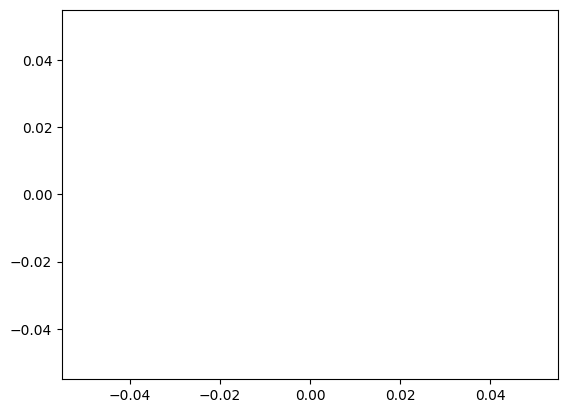

In [25]:
beam.histo1(1)
plt.plot()

In [26]:
print(beam.histo1(1)['histogram'][0])

344.0
